# Example Problem CSE: Elastic Bar in 2D

This notebook solves the two-dimensional elastic bar problem from the task sheet
using NGSolve. It is written in the same spirit as the lecture-note examples:
short derivation, executable cells, intermediate checks, figures, and compact
tables.

The calculation is carried out for group 3 only. All numerical values, plots,
tables, and text answers below refer to this group.


## Strong and Weak Form

The rectangular domain is

$$\Omega = (0,H)\times(0,L),$$

where $y=0$ is the loaded bottom edge and $y=L$ is the clamped top edge.
The displacement is $u=(u_x,u_y)$. Downward load is represented by negative
$y$-direction components:

$$u=0 \quad \text{on } \Gamma_\mathrm{top}, \qquad
\bar t = (0,-t) \quad \text{on } \Gamma_\mathrm{bottom}, \qquad
f=(0,-b) \quad \text{in } \Omega.$$

The missing body-force parameter is selected from density and gravity:

$$b = \rho g.$$

The 2D calculation uses plane stress. With

$$\varepsilon(u)=\frac{1}{2}\left(\nabla u+\nabla u^T\right),$$

the stress tensor is

$$\sigma(u)=2\mu\varepsilon(u)+\lambda_\mathrm{ps}\,
\mathrm{tr}(\varepsilon(u))I,$$

where

$$\mu=\frac{E}{2(1+\nu)}, \qquad
\lambda_\mathrm{ps}=\frac{E\nu}{1-\nu^2}.$$

The weak form is: find $u\in V$, with $V=\{v\in [H^1(\Omega)]^2:
v=0\ \text{on}\ \Gamma_\mathrm{top}\}$, such that

$$\int_\Omega \sigma(u):\varepsilon(v)\,d\Omega
= \int_\Omega f\cdot v\,d\Omega
+ \int_{\Gamma_\mathrm{bottom}}\bar t\cdot v\,ds
\quad \forall v\in V.$$


In [42]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

from ngsolve import *
from ngsolve.meshes import MakeStructured2DMesh

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## Input Parameters

The group 3 parameters from the task sheet are entered below. `E` and `t` are
converted from MPa to Pa for the finite element calculation. The derived line
load at the tip for unit thickness is $F=tH$, and the total body force is
$bHL$.


In [43]:
GROUP_NO = 3
params = dict(
    L=2.76,
    H=0.193,
    E_MPa=189494.0,
    nu=0.23,
    rho=6878.0,
    g=9.81,
    t_MPa=71.0,
)

L = params["L"]
H = params["H"]
E = params["E_MPa"] * 1e6
nu = params["nu"]
rho = params["rho"]
g = params["g"]
t = params["t_MPa"] * 1e6
b = rho * g
F_tip = t * H
F_body_total = b * H * L

selected_parameters = pd.DataFrame(
    {
        "quantity": [
            "group number", "L", "H", "E", "nu", "rho", "g", "t", "b = rho g",
            "F = t H", "total body force b H L"
        ],
        "value": [
            GROUP_NO, L, H, E, nu, rho, g, t, b, F_tip, F_body_total
        ],
        "unit": [
            "-", "m", "m", "Pa", "-", "kg/m^3", "m/s^2", "Pa",
            "N/m^3", "N per unit thickness", "N per unit thickness"
        ],
    }
)

display(selected_parameters)


,quantity,value,unit
0,group number,3.000000e+00,-
1,L,2.760000e+00,m
2,H,1.930000e-01,m
3,E,1.894940e+11,Pa
4,nu,2.300000e-01,-
5,rho,6.878000e+03,kg/m^3
6,g,9.810000e+00,m/s^2
7,t,7.100000e+07,Pa
8,b = rho g,6.747318e+04,N/m^3
9,F = t H,1.370300e+07,N per unit thickness


## Analytical 1D Reference Solution

The analytical reference treats the bar as an axially loaded one-dimensional
member. This is the right comparison for the centerline displacement and the
mean axial stress of the 2D solution.

Equilibrium in the vertical direction gives

$$\frac{d\sigma_{yy}}{dy}-b=0, \qquad \sigma_{yy}(0)=t,$$

so

$$\sigma_{yy}^\mathrm{ana}(y)=t+b y.$$

The maximum axial stress is at the clamped surface:

$$\sigma_{\max,\mathrm{ana}} = t+bL.$$

With $u_y(L)=0$ and $\varepsilon_{yy}=du_y/dy=\sigma_{yy}/E$, the axial
displacement is

$$u_y^\mathrm{ana}(y)
= -\frac{1}{E}\left(t(L-y)+\frac{b}{2}(L^2-y^2)\right).$$

The tip displacement magnitude at $y=0$ is therefore

$$u_\mathrm{tip,ana}=\frac{tL}{E}+\frac{bL^2}{2E}.$$


,quantity,value,unit
0,tip displacement from tip traction,0.001034,m
1,tip displacement from body force,0.000001,m
2,total analytical tip displacement,0.001035,m
3,load percentage,99.869027,%
4,weight percentage,0.130973,%
5,maximum axial stress,71.186226,MPa
6,mean axial stress,71.093113,MPa


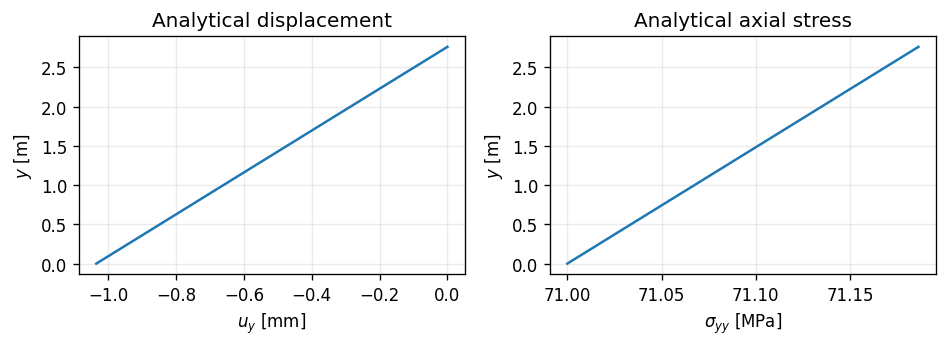

In [44]:
def u_y_analytical(y):
    return -(t * (L - y) + 0.5 * b * (L**2 - y**2)) / E


def sigma_yy_analytical(y):
    return t + b * y


u_load = t * L / E
u_weight = b * L**2 / (2 * E)
u_tip_ana = u_load + u_weight
pct_load = 100 * u_load / u_tip_ana
pct_weight = 100 * u_weight / u_tip_ana
sigma_max_ana = (t + b * L) / 1e6
sigma_mean_ana = (t + 0.5 * b * L) / 1e6

analytical_summary = pd.DataFrame(
    {
        "quantity": [
            "tip displacement from tip traction",
            "tip displacement from body force",
            "total analytical tip displacement",
            "load percentage",
            "weight percentage",
            "maximum axial stress",
            "mean axial stress",
        ],
        "value": [
            u_load,
            u_weight,
            u_tip_ana,
            pct_load,
            pct_weight,
            sigma_max_ana,
            sigma_mean_ana,
        ],
        "unit": ["m", "m", "m", "%", "%", "MPa", "MPa"],
    }
)
display(analytical_summary)

yp = np.linspace(0, L, 300)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.0))
axes[0].plot(u_y_analytical(yp) * 1e3, yp)
axes[0].set_xlabel("$u_y$ [mm]")
axes[0].set_ylabel("$y$ [m]")
axes[0].set_title("Analytical displacement")
axes[1].plot(sigma_yy_analytical(yp) / 1e6, yp)
axes[1].set_xlabel("$\\sigma_{yy}$ [MPa]")
axes[1].set_ylabel("$y$ [m]")
axes[1].set_title("Analytical axial stress")
plt.tight_layout()
plt.show()


## Finite Element Model in NGSolve

The mesh is a structured quadrilateral mesh. The top boundary is fixed by using
`dirichlet="top"` in `VectorH1`. Linear elements are selected with `order=1`;
quadratic elements are selected with `order=2`.


In [45]:
DEFAULT_NX = 4
DEFAULT_NY = max(4, int(round(DEFAULT_NX * L / H)))
DEFAULT_ORDER = 1
SAMPLE_SHAPE = (80, 240)


def make_mesh(nx=DEFAULT_NX, ny=DEFAULT_NY):
    return MakeStructured2DMesh(
        quads=True,
        nx=nx,
        ny=ny,
        mapping=lambda x, y: (H * x, L * y),
    )


def eps(u):
    return Sym(Grad(u))


def sigma(u):
    mu = E / (2 * (1 + nu))
    lam_ps = E * nu / (1 - nu**2)
    return 2 * mu * eps(u) + lam_ps * Trace(eps(u)) * Id(2)


def von_mises_from_stress(stress):
    return sqrt(
        stress[0, 0] ** 2
        - stress[0, 0] * stress[1, 1]
        + stress[1, 1] ** 2
        + 3 * stress[0, 1] ** 2
    )


def sample_coefficient(cf, mesh, nx=60, ny=180, margin_factor=1e-8):
    margin = margin_factor * min(H, L)
    xs = np.linspace(margin, H - margin, nx)
    ys = np.linspace(margin, L - margin, ny)
    values = np.empty((ny, nx))
    for j, yy in enumerate(ys):
        for i, xx in enumerate(xs):
            values[j, i] = float(cf(mesh(xx, yy)))
    return xs, ys, values


def solve_bar(nx=DEFAULT_NX, ny=DEFAULT_NY, order=DEFAULT_ORDER, sample_shape=SAMPLE_SHAPE):
    mesh = make_mesh(nx, ny)
    V = VectorH1(mesh, order=order, dirichlet="top")
    u, v = V.TnT()

    a = BilinearForm(V)
    a += InnerProduct(sigma(u), eps(v)) * dx

    rhs = LinearForm(V)
    rhs += CoefficientFunction((0, -b)) * v * dx
    rhs += CoefficientFunction((0, -t)) * v * ds("bottom")

    a.Assemble()
    rhs.Assemble()

    gfu = GridFunction(V)
    gfu.vec.data = a.mat.Inverse(freedofs=V.FreeDofs()) * rhs.vec

    stress = sigma(gfu)
    vm = von_mises_from_stress(stress)
    xs, ys, vm_values = sample_coefficient(vm, mesh, nx=sample_shape[0], ny=sample_shape[1])
    _, _, disp_norm_values = sample_coefficient(Norm(gfu), mesh, nx=sample_shape[0], ny=sample_shape[1])

    vertex_disp_norms = []
    for vertex in mesh.vertices:
        value = gfu(mesh(vertex.point[0], vertex.point[1]))
        vertex_disp_norms.append(math.hypot(float(value[0]), float(value[1])))

    eps_point = min(H, L) / 1000
    bottom_center = gfu(mesh(H / 2, 0))
    bottom_mean_uy = Integrate(gfu[1] * ds("bottom"), mesh) / H
    mean_syy = Integrate(stress[1, 1], mesh) / (H * L)

    result = {
        "mesh": mesh,
        "V": V,
        "gfu": gfu,
        "stress": stress,
        "von_mises": vm,
        "xs": xs,
        "ys": ys,
        "vm_values": vm_values,
        "disp_norm_values": disp_norm_values,
        "nx": nx,
        "ny": ny,
        "order": order,
        "nodes": mesh.nv,
        "elements": mesh.ne,
        "ndof": V.ndof,
        "free_dofs": sum(1 for is_free in V.FreeDofs() if is_free),
        "fixed_dofs": sum(1 for is_free in V.FreeDofs() if not is_free),
        "ux_tip_center_m": float(bottom_center[0]),
        "uy_tip_center_m": float(bottom_center[1]),
        "uy_tip_mean_bottom_m": float(bottom_mean_uy),
        "u_tip_center_magnitude_m": abs(float(bottom_center[1])),
        "u_tip_mean_magnitude_m": abs(float(bottom_mean_uy)),
        "u_max_fea_m": max(float(np.nanmax(disp_norm_values)), max(vertex_disp_norms)),
        "sigma_yy_mean_MPa": float(mean_syy) / 1e6,
        "sigma_vm_max_sampled_MPa": float(np.nanmax(vm_values)) / 1e6,
        "sigma_vm_corner_top_MPa": float(vm(mesh(eps_point, L - eps_point))) / 1e6,
        "sigma_vm_center_top_MPa": float(vm(mesh(H / 2, L - eps_point))) / 1e6,
    }
    return result


base = solve_bar()

mesh = base["mesh"]
V = base["V"]
gfu = base["gfu"]
stress = base["stress"]
von_mises = base["von_mises"]

print("Boundary names:", mesh.GetBoundaries())
print("Nodes:", base["nodes"])
print("Elements:", base["elements"])
print("Total DOFs:", base["ndof"])
print("Free DOFs:", base["free_dofs"])
print("Fixed DOFs:", base["fixed_dofs"])

base_table = pd.DataFrame(
    {
        "quantity": [
            "tip center ux",
            "tip center uy",
            "tip mean uy on bottom",
            "maximum displacement magnitude",
            "mean sigma_yy",
            "sampled max von Mises stress",
            "von Mises near top corner",
            "von Mises near top center",
        ],
        "value": [
            base["ux_tip_center_m"],
            base["uy_tip_center_m"],
            base["uy_tip_mean_bottom_m"],
            base["u_max_fea_m"],
            base["sigma_yy_mean_MPa"],
            base["sigma_vm_max_sampled_MPa"],
            base["sigma_vm_corner_top_MPa"],
            base["sigma_vm_center_top_MPa"],
        ],
        "unit": ["m", "m", "m", "m", "MPa", "MPa", "MPa", "MPa"],
    }
)
display(base_table)


Boundary names: ('bottom', 'right', 'top', 'left')
Nodes: 290
Elements: 228
Total DOFs: 580
Free DOFs: 570
Fixed DOFs: 10


,quantity,value,unit
0,tip center ux,1.848173e-15,m
1,tip center uy,-1.034812e-03,m
2,tip mean uy on bottom,-1.034811e-03,m
3,maximum displacement magnitude,1.034845e-03,m
4,mean sigma_yy,7.109311e+01,MPa
5,sampled max von Mises stress,7.535842e+01,MPa
6,von Mises near top corner,7.396602e+01,MPa
7,von Mises near top center,6.380217e+01,MPa


## Mesh and Model Questions

**How does mesh size influence displacement and stress results?** A finer mesh
reduces the displacement discretization error and gives a more stable centerline
displacement. Stress is more sensitive because it is computed from displacement
gradients. The stress close to the clamped corners is especially mesh-sensitive
because the fully fixed boundary creates a local stress concentration.

**What is the total number of nodes and elements in the mesh?** The executed
base mesh prints these values above.

**What are the automatically assigned names for the boundaries?** For the
structured rectangle used here NGSolve reports `bottom`, `right`, `top`, and
`left`. If no names are assigned in a custom `SplineGeometry`, NGSolve may report
`default` for all boundary segments, so checking `mesh.GetBoundaries()` is the
safe method.

**How do we select the element order?** The order is selected in the finite
element space:

```python
V = VectorH1(mesh, order=1, dirichlet="top")  # linear
V = VectorH1(mesh, order=2, dirichlet="top")  # quadratic
```

**What is the total number of degrees of freedom?** The executed base model
prints `V.ndof`, plus the number of free and fixed DOFs.

**What physical units are used for $t$ and $b$?** The tip traction $t$ is a
stress/traction. The table gives it in MPa, and the code converts it to Pa. The
body force $b=\rho g$ has units N/m^3. If the weak form is written with MPa
and meters, $b$ can also be written as MPa/m.


## Consistent Nodal Force Vectors

For a bilinear rectangular element of width $h_x$ and height $h_y$, using
the nodal order bottom-left, bottom-right, top-right, top-left and the DOF order

$$(u_{x1},u_{y1},u_{x2},u_{y2},u_{x3},u_{y3},u_{x4},u_{y4}),$$

the body-force part is

$$f_b^e =
\frac{b h_x h_y}{4}
\begin{bmatrix}
0\\-1\\0\\-1\\0\\-1\\0\\-1
\end{bmatrix}.$$

If the bottom edge of this element is on the loaded tip boundary, the traction
part is

$$f_t^e =
\frac{t h_x}{2}
\begin{bmatrix}
0\\-1\\0\\-1\\0\\0\\0\\0
\end{bmatrix}.$$

Therefore $f^e=f_b^e+f_t^e$. For a $2\times2$ patch, the assembled
3-by-3 node pattern of vertical force magnitudes is

$$
\begin{matrix}
bHL/16 & bHL/8 & bHL/16\\
bHL/8  & bHL/4 & bHL/8\\
bHL/16+tH/4 & bHL/8+tH/2 & bHL/16+tH/4
\end{matrix}
$$

with zero horizontal entries and negative sign in the $y$-direction.


In [46]:
hx = H
hy = L
single_body = np.array([0, -b * hx * hy / 4] * 4, dtype=float)
single_tip = np.array([0, -t * hx / 2, 0, -t * hx / 2, 0, 0, 0, 0], dtype=float)
single_total = single_body + single_tip

patch_vertical_magnitudes = np.array(
    [
        [b * H * L / 16, b * H * L / 8, b * H * L / 16],
        [b * H * L / 8, b * H * L / 4, b * H * L / 8],
        [b * H * L / 16 + t * H / 4, b * H * L / 8 + t * H / 2, b * H * L / 16 + t * H / 4],
    ]
)

print("Single element load-only vector f_t^e [N]:")
print(single_tip)
print("Single element body-only vector f_b^e [N]:")
print(single_body)
print("Single element total vector f^e [N]:")
print(single_total)
print("2 x 2 patch vertical force magnitudes [N], top row to bottom row:")
display(pd.DataFrame(patch_vertical_magnitudes, index=["top", "middle", "bottom"], columns=["left", "center", "right"]))


Single element load-only vector f_t^e [N]:
[       0. -6851500.        0. -6851500.        0.        0.        0.
        0.]
Single element body-only vector f_b^e [N]:
[    0.        -8985.4033806     0.        -8985.4033806     0.
 -8985.4033806     0.        -8985.4033806]
Single element total vector f^e [N]:
[       0.        -6860485.4033806        0.        -6860485.4033806
        0.           -8985.4033806        0.           -8985.4033806]
2 x 2 patch vertical force magnitudes [N], top row to bottom row:


,left,center,right
top,2.246351e+03,4.492702e+03,2.246351e+03
middle,4.492702e+03,8.985403e+03,4.492702e+03
bottom,3.427996e+06,6.855993e+06,3.427996e+06


## Displacement Field

The displacement vector stored in `gfu.vec` contains all finite element
coefficients. For the base linear vector space this equals two entries per mesh
node: one $u_x$ and one $u_y$ component.


Number of entries in the displacement vector: 580
V.ndof: 580


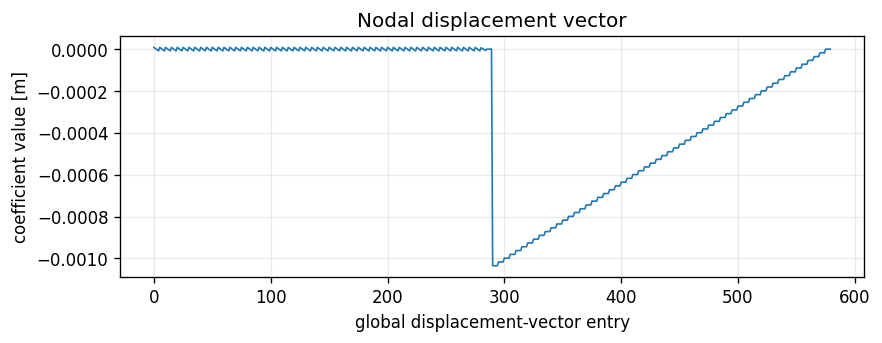

In [47]:
uvec = gfu.vec.FV().NumPy().copy()
print("Number of entries in the displacement vector:", len(uvec))
print("V.ndof:", V.ndof)

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.plot(np.arange(len(uvec)), uvec, lw=1)
ax.set_xlabel("global displacement-vector entry")
ax.set_ylabel("coefficient value [m]")
ax.set_title("Nodal displacement vector")
plt.show()


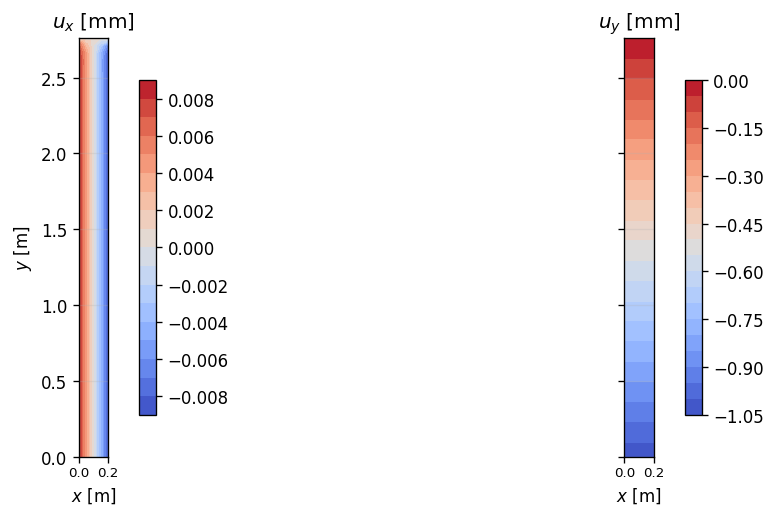

In [48]:
def mesh_triangles(mesh):
    triangles = []
    for el in mesh.Elements(VOL):
        verts = [v.nr for v in el.vertices]
        if len(verts) == 3:
            triangles.append(verts)
        elif len(verts) == 4:
            triangles.append([verts[0], verts[1], verts[2]])
            triangles.append([verts[0], verts[2], verts[3]])
    return np.array(triangles)


def vertex_coordinates(mesh):
    coords = np.array([v.point for v in mesh.vertices], dtype=float)
    return coords[:, 0], coords[:, 1]


def vertex_displacements(mesh, gfu):
    ux = []
    uy = []
    for v in mesh.vertices:
        value = gfu(mesh(v.point[0], v.point[1]))
        ux.append(float(value[0]))
        uy.append(float(value[1]))
    return np.array(ux), np.array(uy)


xv, yv = vertex_coordinates(mesh)
triangles = mesh_triangles(mesh)
uxv, uyv = vertex_displacements(mesh, gfu)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharey=True, constrained_layout=True)

for ax, values, title in [
    (axes[0], uxv * 1e3, "$u_x$ [mm]"),
    (axes[1], uyv * 1e3, "$u_y$ [mm]"),
]:
    cntr = ax.tricontourf(xv, yv, triangles, values, levels=20, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xlabel("$x$ [m]")
    ax.set_aspect("equal")

    ax.set_xticks([0, H])   # or use [0, W] if W is your width variable
    ax.set_xticklabels([f"{0:.1f}", f"{H:.1f}"])
    ax.tick_params(axis="x", labelsize=8, pad=2)

    fig.colorbar(cntr, ax=ax, shrink=0.8)

axes[0].set_ylabel("$y$ [m]")
plt.show()


**How can we display displacement components instead of just magnitudes?** In
NGSolve the vector components are available as coefficient functions via
`gfu[0]` and `gfu[1]`, or equivalently by evaluating the vector-valued grid
function at mesh points. The Matplotlib component plots above use this second
approach by extracting the nodal values of $u_x$ and $u_y$.

```python
value = gfu(mesh(x, y))
u_x = value[0]
u_y = value[1]
```


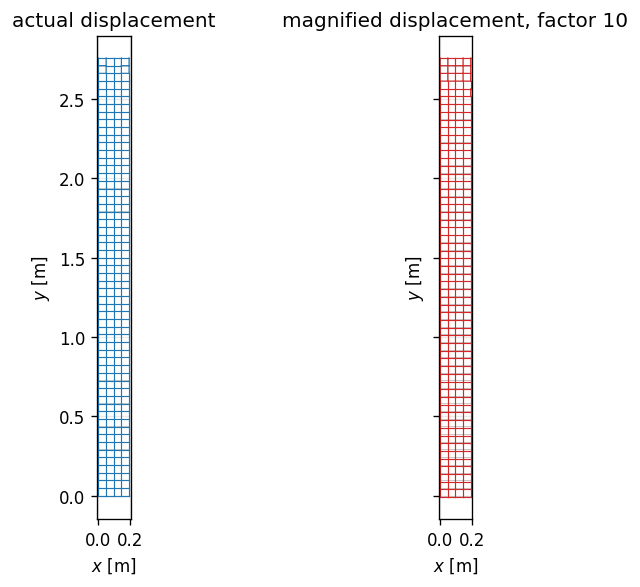

In [49]:
def plot_deformed_mesh(ax, mesh, gfu, scale=1.0, color="#1f77b4"):
    for edge in mesh.edges:
        pts = []
        for v in edge.vertices:
            x, y = mesh.vertices[v.nr].point
            ux, uy = gfu(mesh(x, y))
            pts.append([x + scale * float(ux), y + scale * float(uy)])
        pts = np.array(pts)
        ax.plot(pts[:, 0], pts[:, 1], color=color, lw=0.7)
    ax.set_aspect("equal")
    ax.set_xlabel("$x$ [m]")
    ax.set_ylabel("$y$ [m]")


fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharex=True, sharey=True)
for ax in axes:
    for edge in mesh.edges:
        pts = np.array([mesh.vertices[v.nr].point for v in edge.vertices])
        ax.plot(pts[:, 0], pts[:, 1], color="0.75", lw=0.5)

plot_deformed_mesh(axes[0], mesh, gfu, scale=1.0, color="#1f77b4")
axes[0].set_title("actual displacement")
plot_deformed_mesh(axes[1], mesh, gfu, scale=10.0, color="#d62728")
axes[1].set_title("magnified displacement, factor 10")
plt.tight_layout()
plt.show()


In [50]:
fig, ax = plt.subplots(figsize=(3.6, 5.0))
for edge in mesh.edges:
    pts = np.array([mesh.vertices[v.nr].point for v in edge.vertices])
    ax.plot(pts[:, 0], pts[:, 1], color="0.82", lw=0.4)
animated_lines = []
for edge in mesh.edges:
    line, = ax.plot([], [], color="#d62728", lw=0.65)
    animated_lines.append((line, edge))

ax.set_aspect("equal")
ax.set_xlim(-0.06 * H, 1.06 * H)
ax.set_ylim(-0.04 * L, 1.03 * L)
ax.set_title("deformation animation, scale factor 10")
ax.set_xlabel("$x$ [m]")
ax.set_ylabel("$y$ [m]")


def update(frame):
    alpha = 0.5 * (1 - math.cos(2 * math.pi * frame / 12))
    for line, edge in animated_lines:
        pts = []
        for v in edge.vertices:
            x, y = mesh.vertices[v.nr].point
            ux, uy = gfu(mesh(x, y))
            pts.append([x + 10 * alpha * float(ux), y + 10 * alpha * float(uy)])
        pts = np.array(pts)
        line.set_data(pts[:, 0], pts[:, 1])
    return [line for line, _edge in animated_lines]


anim = FuncAnimation(fig, update, frames=12, interval=120, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())


The animation and the deformed plots show the expected behavior: the top edge
stays fixed, the loaded bottom edge moves downward, and the horizontal
displacement is small and antisymmetric because of Poisson contraction.


## Comparison with the Analytical Displacement


In [51]:
comparison = pd.DataFrame(
    {
        "quantity": [
            "analytical tip displacement magnitude",
            "FEA maximum displacement magnitude",
            "maximum displacement difference FEA - analytical",
            "maximum displacement relative difference",
        ],
        "value": [
            u_tip_ana,
            base["u_max_fea_m"],
            base["u_max_fea_m"] - u_tip_ana,
            (base["u_max_fea_m"] - u_tip_ana) / u_tip_ana * 100,
        ],
        "unit": ["m", "m", "m", "%"],
    }
)
display(comparison)


,quantity,value,unit
0,analytical tip displacement magnitude,1.035479e-03,m
1,FEA maximum displacement magnitude,1.034845e-03,m
2,maximum displacement difference FEA - analytical,-6.340220e-07,m
3,maximum displacement relative difference,-6.122985e-02,%


The FEA displacement is very close to the 1D analytical value. The remaining
difference is expected: the analytical model assumes a perfectly uniaxial stress
state, while the 2D model includes lateral Poisson deformation and a fully fixed
top boundary. The displacement difference magnitude is the absolute value of the
corresponding difference in the table above.


## Stress Field

The next plot shows $\sigma_{yy}$ and the von Mises stress. For an exactly
uniaxial stress state these would be nearly the same in magnitude, but the 2D
clamp introduces transverse and shear stress near the top boundary.


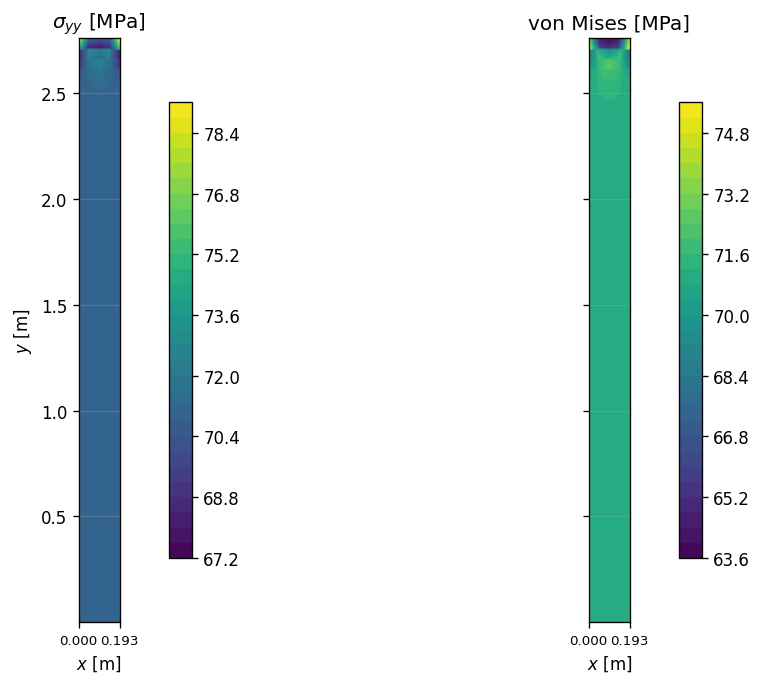

In [52]:
xs, ys, sigma_yy_values = sample_coefficient(stress[1, 1], mesh, nx=SAMPLE_SHAPE[0], ny=SAMPLE_SHAPE[1])
_, _, vm_values = sample_coefficient(von_mises, mesh, nx=SAMPLE_SHAPE[0], ny=SAMPLE_SHAPE[1])
X, Y = np.meshgrid(xs, ys)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 5.6), sharey=True, constrained_layout=True)
plots = [
    (axes[0], sigma_yy_values / 1e6, "$\\sigma_{yy}$ [MPa]"),
    (axes[1], vm_values / 1e6, "von Mises [MPa]"),
]
for ax, values, title in plots:
    cf = ax.contourf(X, Y, values, levels=30, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("$x$ [m]")
    ax.set_aspect("equal")

    ax.set_xticks([0, H])
    ax.set_xticklabels([f"{0:.3f}", f"{H:.3f}"], fontsize=8)

    fig.colorbar(cf, ax=ax, shrink=0.78, pad=0.08)
axes[0].set_ylabel("$y$ [m]")
plt.show()


**What stress quantity is computed using `Norm(..)`?** If `Norm` is applied to
the stress tensor, NGSolve computes the Euclidean/Frobenius tensor norm,

$$\|\sigma\|_F=\sqrt{\sigma_{xx}^2+\sigma_{xy}^2+\sigma_{yx}^2+\sigma_{yy}^2}.$$

This is not the von Mises stress. The von Mises stress for plane stress is

$$\sigma_\mathrm{vM}=\sqrt{\sigma_{xx}^2-\sigma_{xx}\sigma_{yy}
+\sigma_{yy}^2+3\sigma_{xy}^2}.$$

**How can the displayed stress range be adjusted?** In the Matplotlib stress
plot, pass fixed contour levels or use `vmin` and `vmax`:

```python
levels = np.linspace(0, 100, 31)
ax.contourf(X, Y, vm_values/1e6, levels=levels, vmin=0, vmax=100)
```


In [53]:
stress_comparison = pd.DataFrame(
    {
        "quantity": [
            "analytical mean sigma_yy",
            "FEA mean sigma_yy",
            "difference",
            "analytical max axial stress at clamp",
            "sampled max FEA von Mises stress on base mesh",
            "von Mises near clamped corner",
            "von Mises near clamped center",
        ],
        "value_MPa": [
            sigma_mean_ana,
            base["sigma_yy_mean_MPa"],
            base["sigma_yy_mean_MPa"] - sigma_mean_ana,
            sigma_max_ana,
            base["sigma_vm_max_sampled_MPa"],
            base["sigma_vm_corner_top_MPa"],
            base["sigma_vm_center_top_MPa"],
        ],
    }
)
display(stress_comparison)


,quantity,value_MPa
0,analytical mean sigma_yy,7.109311e+01
1,FEA mean sigma_yy,7.109311e+01
2,difference,-1.108447e-12
3,analytical max axial stress at clamp,7.118623e+01
4,sampled max FEA von Mises stress on base mesh,7.535842e+01
5,von Mises near clamped corner,7.396602e+01
6,von Mises near clamped center,6.380217e+01


The mean FEA $\sigma_{yy}$ is consistent with the analytical mean stress. This
is a useful equilibrium check: the average axial stress is governed by the
resultant tip traction and body force. The pointwise von Mises stress differs
near the clamp because the 2D model has transverse stress and shear components,
especially near the fixed corners.

Because the maximum occurs close to the clamped corner, it changes under mesh
and order refinement. The mean stress is therefore the more robust equilibrium
check, while the maximum von Mises stress is mainly used as a local,
mesh-dependent stress indicator.

The corner and center stresses at the clamped surface differ because the corner
combines a fixed displacement boundary, a free side boundary, and Poisson
constraint effects. This produces a local stress concentration. The center of
the clamped edge is less affected by the free side edge and therefore has a
different stress state.


## Mesh Refinement and Element Order Studies


,nx,ny,nodes,elements,ndof,u_max_FEA_m,u_max_error_m,mean_sigma_yy_MPa,sampled_max_vM_MPa
0,2,29,90,58,180,0.001035,-8.228093e-07,71.093113,73.130080
1,4,57,290,228,580,0.001035,-6.340220e-07,71.093113,75.358421
2,8,114,1035,912,2070,0.001035,-5.529609e-07,71.093113,82.248934
3,12,172,2249,2064,4498,0.001035,-5.299718e-07,71.093113,88.569042


,order,nodes,elements,ndof,u_max_FEA_m,u_max_error_m,mean_sigma_yy_MPa,sampled_max_vM_MPa
0,1,290,228,580,0.001035,-6.340220e-07,71.093113,75.358421
1,2,290,228,2070,0.001035,-5.261327e-07,71.093113,91.414267


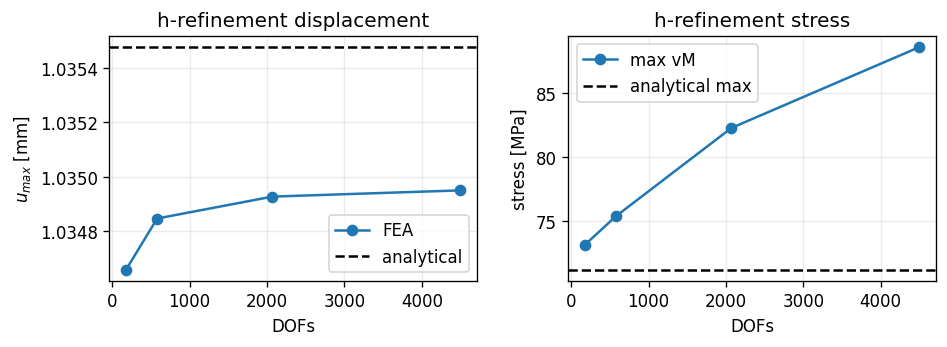

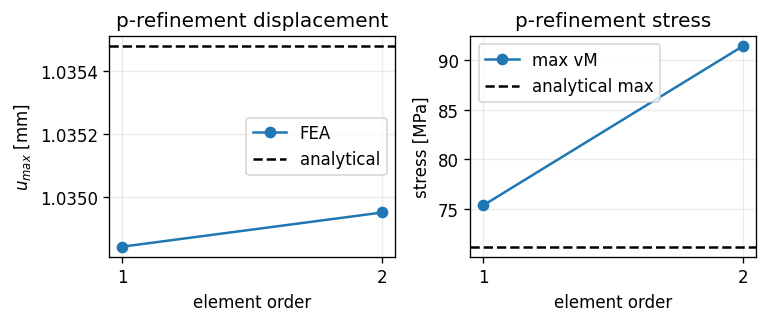

In [54]:
h_rows = []
for nx in [2, 4, 8, 12]:
    ny = max(4, int(round(nx * L / H)))
    res = solve_bar(nx=nx, ny=ny, order=1, sample_shape=SAMPLE_SHAPE)
    h_rows.append(
        {
            "nx": nx,
            "ny": ny,
            "nodes": res["nodes"],
            "elements": res["elements"],
            "ndof": res["ndof"],
            "u_max_FEA_m": res["u_max_fea_m"],
            "u_max_error_m": res["u_max_fea_m"] - u_tip_ana,
            "mean_sigma_yy_MPa": res["sigma_yy_mean_MPa"],
            "sampled_max_vM_MPa": res["sigma_vm_max_sampled_MPa"],
        }
    )

h_table = pd.DataFrame(h_rows)
display(h_table)

p_rows = []
for order in [1, 2]:
    res = solve_bar(nx=DEFAULT_NX, ny=DEFAULT_NY, order=order, sample_shape=SAMPLE_SHAPE)
    p_rows.append(
        {
            "order": order,
            "nodes": res["nodes"],
            "elements": res["elements"],
            "ndof": res["ndof"],
            "u_max_FEA_m": res["u_max_fea_m"],
            "u_max_error_m": res["u_max_fea_m"] - u_tip_ana,
            "mean_sigma_yy_MPa": res["sigma_yy_mean_MPa"],
            "sampled_max_vM_MPa": res["sigma_vm_max_sampled_MPa"],
        }
    )

p_table = pd.DataFrame(p_rows)
display(p_table)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.0))
axes[0].plot(h_table["ndof"], h_table["u_max_FEA_m"] * 1e3, "o-", label="FEA")
axes[0].axhline(u_tip_ana * 1e3, color="black", ls="--", label="analytical")
axes[0].set_xlabel("DOFs")
axes[0].set_ylabel("$u_{max}$ [mm]")
axes[0].set_title("h-refinement displacement")
axes[0].legend()

axes[1].plot(h_table["ndof"], h_table["sampled_max_vM_MPa"], "o-", label="max vM")
axes[1].axhline(sigma_max_ana, color="black", ls="--", label="analytical max")
axes[1].set_xlabel("DOFs")
axes[1].set_ylabel("stress [MPa]")
axes[1].set_title("h-refinement stress")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.8))
axes[0].plot(p_table["order"], p_table["u_max_FEA_m"] * 1e3, "o-", label="FEA")
axes[0].axhline(u_tip_ana * 1e3, color="black", ls="--", label="analytical")
axes[0].set_xticks(p_table["order"])
axes[0].set_xlabel("element order")
axes[0].set_ylabel("$u_{max}$ [mm]")
axes[0].set_title("p-refinement displacement")
axes[0].legend()

axes[1].plot(p_table["order"], p_table["sampled_max_vM_MPa"], "o-", label="max vM")
axes[1].axhline(sigma_max_ana, color="black", ls="--", label="analytical max")
axes[1].set_xticks(p_table["order"])
axes[1].set_xlabel("element order")
axes[1].set_ylabel("stress [MPa]")
axes[1].set_title("p-refinement stress")
axes[1].legend()
plt.tight_layout()
plt.show()


Under h-refinement the displacement changes only slightly and approaches a
stable 2D value. The mean $\sigma_{yy}$ remains essentially identical to the
analytical value because it is controlled by force equilibrium. The sampled
maximum von Mises stress is more sensitive to mesh size because the largest
values occur close to the clamped corners.

Under p-refinement, changing `order=1` to `order=2` increases the number of DOFs
on the same mesh and improves the displacement approximation. The p-refinement
plot compares both the maximum displacement and sampled maximum von Mises stress
for the two element orders. Stress gradients are represented better with
quadratic elements, but stress concentrations near the clamp still remain local
and mesh-sensitive.


## Result Table


In [55]:
results_table = pd.DataFrame(
    [
        {
            "Group No": GROUP_NO,
            "u_max,ana [m]": u_tip_ana,
            "u_max,FEA [m]": base["u_max_fea_m"],
            "sigma_max,ana [MPa]": sigma_max_ana,
            "sampled sigma_max,vM,FEA [MPa]": base["sigma_vm_max_sampled_MPa"],
        }
    ]
)
display(results_table)

print(
    "The reported FEA von Mises maximum is the sampled maximum obtained on the "
    f"selected base mesh (nx={DEFAULT_NX}, ny={DEFAULT_NY}, order={DEFAULT_ORDER}, "
    f"sampling grid {SAMPLE_SHAPE[0]} x {SAMPLE_SHAPE[1]}). The refinement study "
    "shows that this local maximum near the clamped corners is mesh-sensitive. "
    "Therefore, this value should be interpreted as a mesh-dependent stress "
    "indicator, not as a converged pointwise maximum stress."
)

csv_values = [
    str(GROUP_NO),
    f"{u_tip_ana:.12g}",
    f"{base['u_max_fea_m']:.12g}",
    f"{sigma_max_ana:.12g}",
    f"{base['sigma_vm_max_sampled_MPa']:.12g}",
]

with open("results.csv", "w", encoding="utf-8") as fp:
    fp.write(";".join(csv_values) + "\n")

print("CSV line:")
print(";".join(csv_values))

,Group No,"u_max,ana [m]","u_max,FEA [m]","sigma_max,ana [MPa]","sampled sigma_max,vM,FEA [MPa]"
0,3,0.001035,0.001035,71.186226,75.358421


The reported FEA von Mises maximum is the sampled maximum obtained on the selected base mesh (nx=4, ny=57, order=1, sampling grid 80 x 240). The refinement study shows that this local maximum near the clamped corners is mesh-sensitive. Therefore, this value should be interpreted as a mesh-dependent stress indicator, not as a converged pointwise maximum stress.
CSV line:
3;0.00103547865288;0.00103484463085;71.1862259768;75.3584205596
